In [5]:
%pip install pandas
%pip install pandas numpy matplotlib scikit-learn
%pip install --upgrade scikit-learn
%pip install --upgrade matplotlib
%pip install --upgrade pandas




Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
#Loading the dataset
df = pd.read_csv("winequality.csv")


In [8]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [9]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (1599, 12)

Columns:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

Data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 

In [10]:
print("Quality value counts:")
print(df["quality"].value_counts().sort_index())

Quality value counts:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [11]:
df["good_quality"] = df["quality"].apply(lambda x: 1 if x >= 7 else 0)
df[["quality", "good_quality"]].head()

,quality,good_quality
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


In [12]:
print("Binary target distribution:")
print(df["good_quality"].value_counts())

Binary target distribution:
good_quality
0    1382
1     217
Name: count, dtype: int64


In [13]:
X = df.drop(["quality", "good_quality"], axis=1)
y = df["good_quality"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.head()


Feature matrix shape: (1599, 11)
Target shape: (1599,)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1279, 11)
X_test shape: (320, 11)
y_train shape: (1279,)
y_test shape: (320,)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, lr_preds))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, lr_preds))

Logistic Regression Accuracy: 0.89375

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       277
           1       0.74      0.33      0.45        43

    accuracy                           0.89       320
   macro avg       0.82      0.65      0.70       320
weighted avg       0.88      0.89      0.88       320


Confusion Matrix:

[[272   5]
 [ 29  14]]


In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_preds))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, rf_preds))

Random Forest Accuracy: 0.94375

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       277
           1       0.93      0.63      0.75        43

    accuracy                           0.94       320
   macro avg       0.94      0.81      0.86       320
weighted avg       0.94      0.94      0.94       320


Confusion Matrix:

[[275   2]
 [ 16  27]]


In [17]:
lr_acc = accuracy_score(y_test, lr_preds)
rf_acc = accuracy_score(y_test, rf_preds)

print("Model Comparison")
print("----------------")
print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)

Model Comparison
----------------
Logistic Regression Accuracy: 0.89375
Random Forest Accuracy: 0.94375


In [18]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("Feature Importances:")
print(importances)

Feature Importances:
alcohol                 0.173743
sulphates               0.111262
density                 0.103162
volatile acidity        0.102414
citric acid             0.092871
total sulfur dioxide    0.078284
fixed acidity           0.076361
residual sugar          0.069339
chlorides               0.068312
pH                      0.065180
free sulfur dioxide     0.059073
dtype: float64


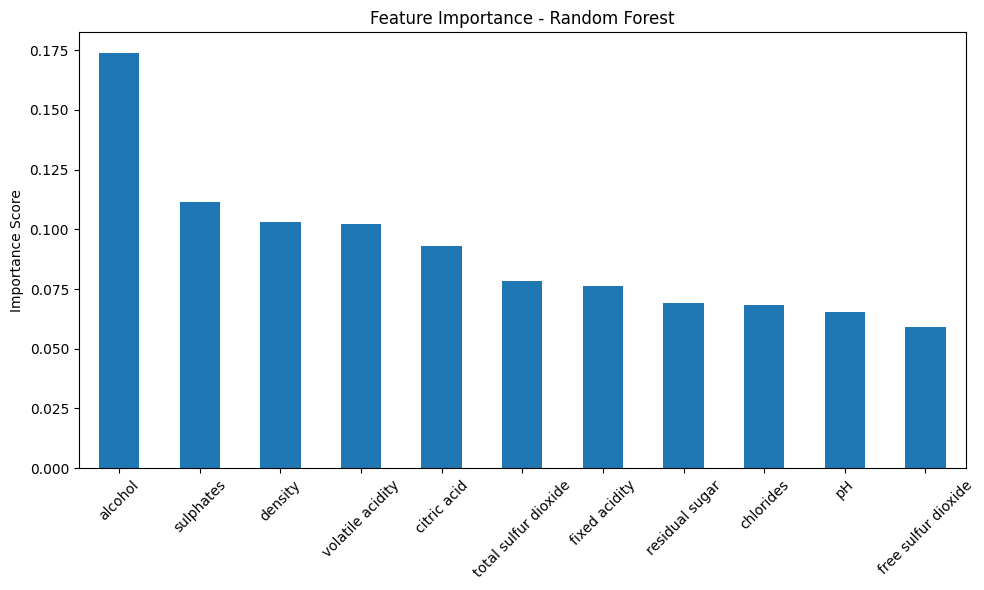

In [19]:
plt.figure(figsize=(10, 6))
importances.plot(kind="bar")
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

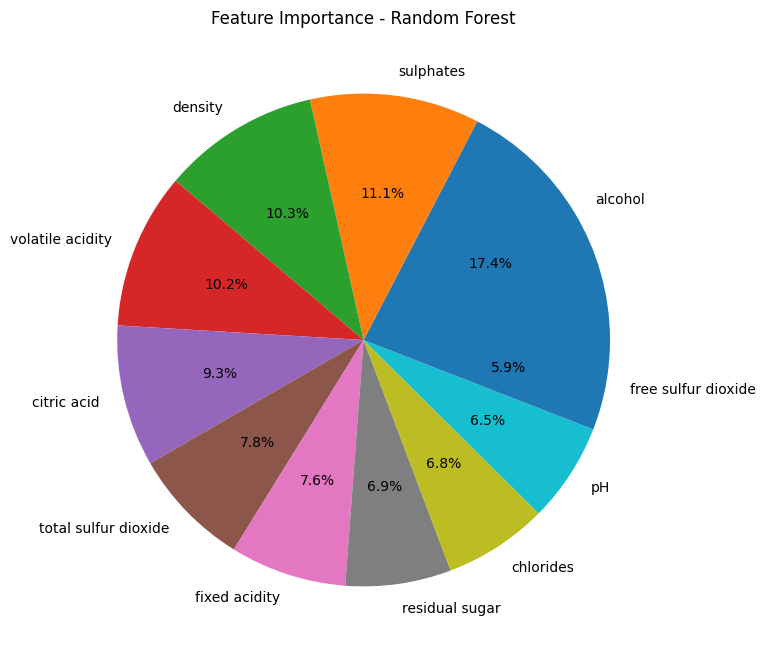

In [20]:
plt.figure(figsize=(8, 8))
importances.plot(kind='pie', autopct='%1.1f%%')
plt.title("Feature Importance - Random Forest")
plt.ylabel('')
plt.show()

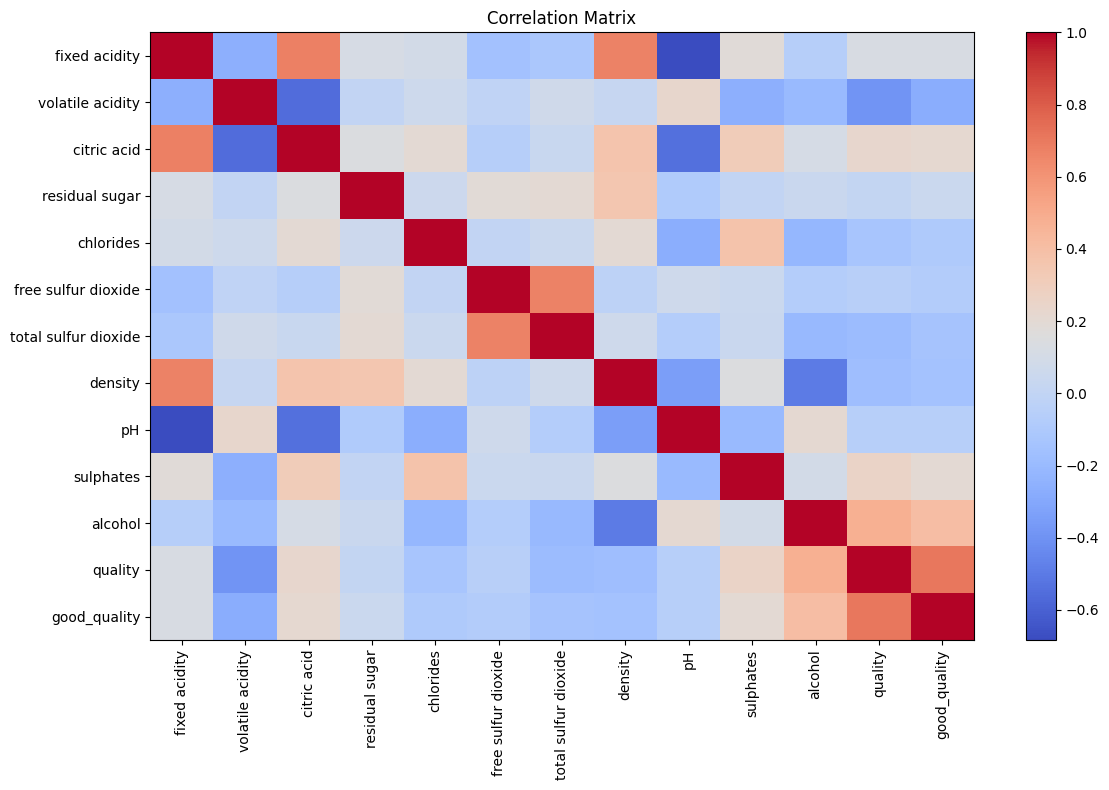

In [21]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()